## Prediction performance comparison with baseline fully connected neural networks

While the partial connections of GenNet significantly reduce parameter count and therefore risk of overfitting, it also potentially reduces prediction performance when annotation data quality is unreliable and strong main/interaction effects occur outside of the defined topology. We aim to answer the question: does partial connectivity improve prediction performance compared to fully connected neural networks? 

### Approach
We compare GenNet to a fully connected neural network with **matched parameter count** to ensure a fair comparison that isolates the effect of connectivity pattern from model capacity.

### GenNet Parameter Count (Reference)
- Layer 1 (SNP → Gene): ~10,000 sparse connections + 500 biases ≈ 10,500 params
- Layer 2 (Gene → Output): 500 weights + 1 bias = 501 params  
- **Total: ~11,000 parameters**

### FCNN-Matched Architecture
To match ~11,000 parameters with a fully connected network:
- Input: 10,000 SNPs
- Hidden: 1 neuron (10,000 × 1 + 1 = 10,001 params)
- Output: 1 neuron (1 × 1 + 1 = 2 params)
- **Total: ~10,003 parameters**

Note: With a 1-neuron bottleneck, the FCNN essentially becomes a linear model. For a more meaningful comparison, we also test a regularized FCNN with more neurons.

In [4]:
import tensorflow as tf
from tensorflow import keras 
import numpy as np 
import pandas as pd
import tables
import matplotlib.pyplot as plt 
from pathlib import Path
from sklearn.metrics import r2_score, mean_squared_error
plt.style.use('bmh')

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.9.0


### Configuration

In [5]:
# Paths
base_dir = Path('../data/processed/pure_grid_experiments')
h5_path = Path('../data/processed/pure_simulation/h5_output/genotype.h5')
results_dir = Path('../results/fcnn_experiments')
results_dir.mkdir(parents=True, exist_ok=True)

# Model training settings
lr = 0.001
batch_size = 32
n_epochs = 150
patience = 10

# ============================================================
# REDUCED EXPERIMENT GRID (2 configurations only)
# ============================================================
# Selected configurations:
# 1. N=15000, P=50, h²=0.6, α=0 (additive, moderate polygenicity)
# 2. N=15000, P=50, h²=0.6, α=1 (epistatic, same setup)
# This allows comparison of additive vs epistatic with large sample size

p_values = [50]
h2_values = [0.6]
n_train_values = [15000]
alpha_values = [0, 1]  # additive and epistatic only

# Fixed parameters
n_snps = 10000
n_genes = 500

print(f"Experiment grid (REDUCED for computational efficiency):")
print(f"  P values: {p_values}")
print(f"  h² values: {h2_values}")
print(f"  N_train values: {n_train_values}")
print(f"  Alpha values: {alpha_values}")
print(f"  Total experiments: {len(p_values) * len(h2_values) * len(n_train_values) * len(alpha_values)}")

Experiment grid (REDUCED for computational efficiency):
  P values: [50]
  h² values: [0.6]
  N_train values: [15000]
  Alpha values: [0, 1]
  Total experiments: 2


### Calculate GenNet Parameter Count

In [6]:
def calculate_gennet_params(n_snps, n_genes, snps_per_gene=None):
    """
    Calculate GenNet parameter count based on topology.
    
    GenNet uses LocallyDirected1D layers where the number of weights
    equals the number of non-zero entries in the sparse mask.
    
    For the pure simulation setup:
    - Each SNP connects to exactly 1 gene (contiguous assignment)
    - So the mask has n_snps non-zero entries
    """
    if snps_per_gene is None:
        snps_per_gene = n_snps // n_genes
    
    # Layer 1: SNP -> Gene (LocallyDirected1D)
    # Kernel: n_connections (= n_snps since each SNP connects to 1 gene)
    # Bias: n_genes
    layer1_weights = n_snps  # sparse connections
    layer1_bias = n_genes
    layer1_total = layer1_weights + layer1_bias
    
    # Layer 2: Gene -> Output (Dense)
    # Kernel: n_genes × 1
    # Bias: 1
    layer2_weights = n_genes
    layer2_bias = 1
    layer2_total = layer2_weights + layer2_bias
    
    total = layer1_total + layer2_total
    
    print(f"GenNet Parameter Count:")
    print(f"  Layer 1 (SNP→Gene): {layer1_weights} weights + {layer1_bias} biases = {layer1_total}")
    print(f"  Layer 2 (Gene→Output): {layer2_weights} weights + {layer2_bias} biases = {layer2_total}")
    print(f"  Total: {total} parameters")
    
    return total

gennet_params = calculate_gennet_params(n_snps, n_genes)

GenNet Parameter Count:
  Layer 1 (SNP→Gene): 10000 weights + 500 biases = 10500
  Layer 2 (Gene→Output): 500 weights + 1 biases = 501
  Total: 11001 parameters


### FCNN Architectures

We implement multiple FCNN baselines:

1. **FCNN-Matched**: Same parameter count as GenNet (~11,000)
   - This results in a very small hidden layer (essentially linear)
   
2. **FCNN-Same-Shape**: Same layer dimensions as GenNet (500 hidden units)
   - Much larger parameter count (~5M), requires heavy regularization

3. **FCNN-Regularized**: Medium hidden layer with L1 regularization sweep

In [7]:
def create_fcnn_matched(n_snps, target_params, l1_lambda=0.01, activation='relu'):
    """
    Create FCNN with approximately matched parameter count to GenNet.
    
    For n_snps=10000 and target_params~11000:
    Dense(H): n_snps × H + H params
    Dense(1): H × 1 + 1 params
    Total: n_snps × H + 2H + 1
    
    Solving for H: H ≈ target_params / (n_snps + 2) ≈ 1
    
    Since H=1 makes it essentially linear, we use the closest meaningful value.
    """
    # Calculate hidden units to match parameters
    # total_params = n_snps * H + H + H + 1 = H * (n_snps + 2) + 1
    H = max(1, int((target_params - 1) / (n_snps + 2)))
    
    actual_params = H * (n_snps + 2) + 1
    
    print(f"FCNN-Matched Architecture:")
    print(f"  Input: {n_snps}")
    print(f"  Hidden: {H}")
    print(f"  Output: 1")
    print(f"  Target params: {target_params}, Actual: {actual_params}")
    
    model = keras.models.Sequential([
        keras.Input(shape=(n_snps,)),
        keras.layers.BatchNormalization(center=False, scale=False),
        keras.layers.Dense(H, activation=activation,
                          kernel_regularizer=keras.regularizers.l1(l1_lambda)),
        keras.layers.BatchNormalization(center=False, scale=False),
        keras.layers.Dense(1, activation='linear',
                          kernel_regularizer=keras.regularizers.l1(l1_lambda))
    ])
    
    return model, H


def create_fcnn_same_shape(n_snps, n_hidden, l1_lambda=0.01, activation='relu'):
    """
    Create FCNN with same layer dimensions as GenNet.
    
    This has MANY more parameters than GenNet:
    Dense(500): 10000 × 500 + 500 = 5,000,500 params
    Dense(1): 500 × 1 + 1 = 501 params
    Total: ~5,001,001 params (vs GenNet's ~11,000)
    """
    total_params = n_snps * n_hidden + n_hidden + n_hidden + 1
    
    print(f"FCNN-Same-Shape Architecture:")
    print(f"  Input: {n_snps}")
    print(f"  Hidden: {n_hidden}")
    print(f"  Output: 1")
    print(f"  Total params: {total_params:,}")
    
    model = keras.models.Sequential([
        keras.Input(shape=(n_snps,)),
        keras.layers.BatchNormalization(center=False, scale=False),
        keras.layers.Dense(n_hidden, activation=activation,
                          kernel_regularizer=keras.regularizers.l1(l1_lambda)),
        keras.layers.BatchNormalization(center=False, scale=False),
        keras.layers.Dense(1, activation='linear',
                          kernel_regularizer=keras.regularizers.l1(l1_lambda))
    ])
    
    return model


# Test model creation
print("="*60)
model_matched, H = create_fcnn_matched(n_snps, gennet_params)
print(f"\nModel summary:")
model_matched.summary()

print("\n" + "="*60)
model_same_shape = create_fcnn_same_shape(n_snps, n_genes)
print(f"\nModel summary:")
model_same_shape.summary()

FCNN-Matched Architecture:
  Input: 10000
  Hidden: 1
  Output: 1
  Target params: 11001, Actual: 10003
Metal device set to: Apple M4

systemMemory: 16.00 GB
maxCacheSize: 5.92 GB



2026-01-22 09:38:06.155998: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-22 09:38:06.157907: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



Model summary:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization (BatchN  (None, 10000)            20000     
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 1)                 10001     
                                                                 
 batch_normalization_1 (Batc  (None, 1)                2         
 hNormalization)                                                 
                                                                 
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 30,005
Trainable params: 10,003
Non-trainable params: 20,002
_________________________________________________________________

FCNN-Same-Shape Architecture:


### Data Loading Functions

In [8]:
def load_genotype_data(h5_path):
    """
    Load genotype matrix from HDF5 file.
    
    The genotype.h5 file contains:
    - 'data': array of shape (n_samples, n_snps)
    """
    with tables.open_file(str(h5_path), 'r') as h5:
        genotype_matrix = h5.root.data[:]
    
    print(f"Loaded genotype matrix: {genotype_matrix.shape}")
    return genotype_matrix


def load_experiment_data(exp_dir, genotype_matrix):
    """
    Load experiment data (phenotypes, train/val/test splits).
    
    subjects.csv contains:
    - patient_id: sample identifier
    - labels: phenotype values
    - genotype_row: row index in genotype matrix
    - set: 1=train, 2=val, 3=test
    """
    subjects_df = pd.read_csv(exp_dir / 'subjects.csv')
    
    # Split by set
    train_mask = subjects_df['set'] == 1
    val_mask = subjects_df['set'] == 2
    test_mask = subjects_df['set'] == 3
    
    # Get indices and labels
    train_idx = subjects_df[train_mask]['genotype_row'].values
    val_idx = subjects_df[val_mask]['genotype_row'].values
    test_idx = subjects_df[test_mask]['genotype_row'].values
    
    y_train = subjects_df[train_mask]['labels'].values
    y_val = subjects_df[val_mask]['labels'].values
    y_test = subjects_df[test_mask]['labels'].values
    
    # Get genotype data
    X_train = genotype_matrix[train_idx]
    X_val = genotype_matrix[val_idx]
    X_test = genotype_matrix[test_idx]
    
    print(f"  Train: {X_train.shape[0]} samples")
    print(f"  Val: {X_val.shape[0]} samples")
    print(f"  Test: {X_test.shape[0]} samples")
    
    return X_train, X_val, X_test, y_train, y_val, y_test


# Load genotype matrix (shared across all experiments)
genotype_matrix = load_genotype_data(h5_path)

Loaded genotype matrix: (25000, 10000)


### Training Function

In [9]:
def train_fcnn(model, X_train, y_train, X_val, y_val, 
               lr=0.001, batch_size=32, epochs=150, patience=10, verbose=0):
    """
    Train FCNN model with early stopping.
    """
    # Compile model
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, 
                  loss='mean_squared_error',
                  metrics=['mean_squared_error'])
    
    # Callbacks
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )
    
    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=verbose
    )
    
    return history


def evaluate_model(model, X_test, y_test):
    """
    Evaluate model and return R² and MSE.
    """
    y_pred = model.predict(X_test, verbose=0).flatten()
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    return r2, mse

### Run Experiments

In [10]:
# Initialize results
results_same_shape = []

# L1 regularization values to test for same-shape model
l1_values_same_shape = [0.01, 0.1, 1.0]

total_experiments = len(p_values) * len(h2_values) * len(n_train_values) * len(alpha_values)
exp_count = 0

print("="*70)
print("RUNNING FCNN EXPERIMENTS (Same-Shape Only)")
print("="*70)

for n_train in n_train_values:
    for P in p_values:
        for h2 in h2_values:
            for alpha in alpha_values:
                exp_count += 1
                exp_id = f"exp_N{n_train}_P{P}_h2{h2}_alpha{alpha}"
                exp_dir = base_dir / exp_id
                
                if not exp_dir.exists():
                    print(f"[{exp_count}/{total_experiments}] {exp_id} - SKIP (not found)")
                    continue
                
                print(f"\n[{exp_count}/{total_experiments}] {exp_id}")
                
                # Load data
                X_train, X_val, X_test, y_train, y_val, y_test = load_experiment_data(
                    exp_dir, genotype_matrix
                )
                
                # ============================================
                # FCNN-Same-Shape (with regularization sweep)
                # ============================================
                best_val_r2 = -np.inf
                best_l1 = None
                best_result = None
                
                for l1_val in l1_values_same_shape:
                    print(f"  Training FCNN-Same-Shape (L1={l1_val})...")
                    tf.keras.backend.clear_session()
                    
                    model_same = create_fcnn_same_shape(
                        n_snps, n_genes, l1_lambda=l1_val, activation='relu'
                    )
                    
                    history = train_fcnn(
                        model_same, X_train, y_train, X_val, y_val,
                        lr=lr, batch_size=batch_size, epochs=n_epochs,
                        patience=patience, verbose=0
                    )
                    
                    test_r2_ss, test_mse_ss = evaluate_model(model_same, X_test, y_test)
                    val_r2_ss, val_mse_ss = evaluate_model(model_same, X_val, y_val)
                    
                    result = {
                        'experiment_id': exp_id,
                        'n_train': n_train,
                        'P': P,
                        'h2': h2,
                        'alpha': alpha,
                        'model_type': 'FCNN-Same-Shape',
                        'hidden_units': n_genes,
                        'l1_lambda': l1_val,
                        'test_r2': test_r2_ss,
                        'test_mse': test_mse_ss,
                        'val_r2': val_r2_ss,
                        'val_mse': val_mse_ss,
                        'epochs_trained': len(history.history['loss'])
                    }
                    
                    print(f"    L1={l1_val}: Test R²={test_r2_ss:.4f}, Val R²={val_r2_ss:.4f}")
                    
                    if val_r2_ss > best_val_r2:
                        best_val_r2 = val_r2_ss
                        best_l1 = l1_val
                        best_result = result
                
                # Store best same-shape result
                if best_result is not None:
                    results_same_shape.append(best_result)
                    print(f"    Best FCNN-Same-Shape: L1={best_l1}, Test R²={best_result['test_r2']:.4f}")

print("\n" + "="*70)
print("EXPERIMENTS COMPLETE")
print("="*70)

RUNNING FCNN EXPERIMENTS (Same-Shape Only)

[1/2] exp_N15000_P50_h20.6_alpha0
  Train: 15000 samples
  Val: 3000 samples
  Test: 3000 samples
  Training FCNN-Same-Shape (L1=0.01)...
FCNN-Same-Shape Architecture:
  Input: 10000
  Hidden: 500
  Output: 1
  Total params: 5,001,001


2026-01-22 09:43:24.551629: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2026-01-22 09:43:25.421344: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2026-01-22 09:43:32.303627: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2026-01-22 09:44:28.330594: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


    L1=0.01: Test R²=0.0320, Val R²=0.0413
  Training FCNN-Same-Shape (L1=0.1)...
FCNN-Same-Shape Architecture:
  Input: 10000
  Hidden: 500
  Output: 1
  Total params: 5,001,001


2026-01-22 09:44:30.070227: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2026-01-22 09:44:35.551118: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2026-01-22 09:45:29.142879: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


    L1=0.1: Test R²=-0.0005, Val R²=-0.0011
  Training FCNN-Same-Shape (L1=1.0)...
FCNN-Same-Shape Architecture:
  Input: 10000
  Hidden: 500
  Output: 1
  Total params: 5,001,001


...

    L1=0.01: Test R²=0.0098, Val R²=0.0107
  Training FCNN-Same-Shape (L1=0.1)...
FCNN-Same-Shape Architecture:
  Input: 10000
  Hidden: 500
  Output: 1
  Total params: 5,001,001


2026-01-22 09:55:59.209067: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2026-01-22 09:56:04.669631: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2026-01-22 09:56:57.955881: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


    L1=0.1: Test R²=-0.0008, Val R²=-0.0008
  Training FCNN-Same-Shape (L1=1.0)...
FCNN-Same-Shape Architecture:
  Input: 10000
  Hidden: 500
  Output: 1
  Total params: 5,001,001


2026-01-22 09:56:59.687301: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2026-01-22 09:57:05.226531: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2026-01-22 10:02:39.993009: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


    L1=1.0: Test R²=-0.0008, Val R²=-0.0007
    Best FCNN-Same-Shape: L1=0.01, Test R²=0.0098

EXPERIMENTS COMPLETE


### Save Results

In [11]:
# Save results to CSV
df_same_shape = pd.DataFrame(results_same_shape)
df_same_shape.to_csv(results_dir / 'fcnn_same_shape_results.csv', index=False)

print(f"Results saved to {results_dir}")
print(f"  - fcnn_same_shape_results.csv: {len(df_same_shape)} experiments")
print(f"\nResults:")
df_same_shape

Results saved to ../results/fcnn_experiments
  - fcnn_same_shape_results.csv: 2 experiments

Results:


,experiment_id,n_train,P,h2,alpha,model_type,hidden_units,l1_lambda,test_r2,test_mse,val_r2,val_mse,epochs_trained
0,exp_N15000_P50_h20.6_alpha0,15000,50,0.6,0,FCNN-Same-Shape,500,0.01,0.032018,0.970714,0.041274,0.961867,11
1,exp_N15000_P50_h20.6_alpha1,15000,50,0.6,1,FCNN-Same-Shape,500,0.01,0.009800,1.046337,0.010748,0.975800,11


### Results Analysis

In [12]:
# Load GenNet results for comparison
gennet_relu = pd.read_csv('../results/pure_grid_results_relu.csv')
gennet_relu['model_type'] = 'GenNet-ReLU'

# Filter to matching experiments only
gennet_subset = gennet_relu[
    (gennet_relu['P'].isin(p_values)) & 
    (gennet_relu['n_train'].isin(n_train_values)) &
    (gennet_relu['alpha'].isin(alpha_values))
]

# Combine results
df_same_shape['model_type'] = 'FCNN-Same-Shape'

all_results = pd.concat([
    gennet_subset[['experiment_id', 'n_train', 'P', 'h2', 'alpha', 'test_r2', 'model_type']],
    df_same_shape[['experiment_id', 'n_train', 'P', 'h2', 'alpha', 'test_r2', 'model_type']]
], ignore_index=True)

print("="*60)
print("COMPARISON: GenNet vs FCNN-Same-Shape")
print("="*60)

# Summary by model type
print("\n--- Test R² by Model Type ---")
print(all_results.groupby('model_type')['test_r2'].agg(['mean', 'std', 'min', 'max']))

# Summary by alpha (additive vs epistatic)
print("\n--- Test R² by Model Type and Alpha ---")
summary = all_results.groupby(['model_type', 'alpha'])['test_r2'].mean().unstack()
print(summary)

COMPARISON: GenNet vs FCNN-Same-Shape

--- Test R² by Model Type ---
                     mean       std       min       max
model_type                                             
FCNN-Same-Shape  0.020909  0.015711  0.009800  0.032018
GenNet-ReLU      0.396001  0.083953  0.336637  0.455365

--- Test R² by Model Type and Alpha ---
alpha                 0.0       1.0
model_type                         
FCNN-Same-Shape  0.032018  0.009800
GenNet-ReLU      0.455365  0.336637


### Comparison Plots

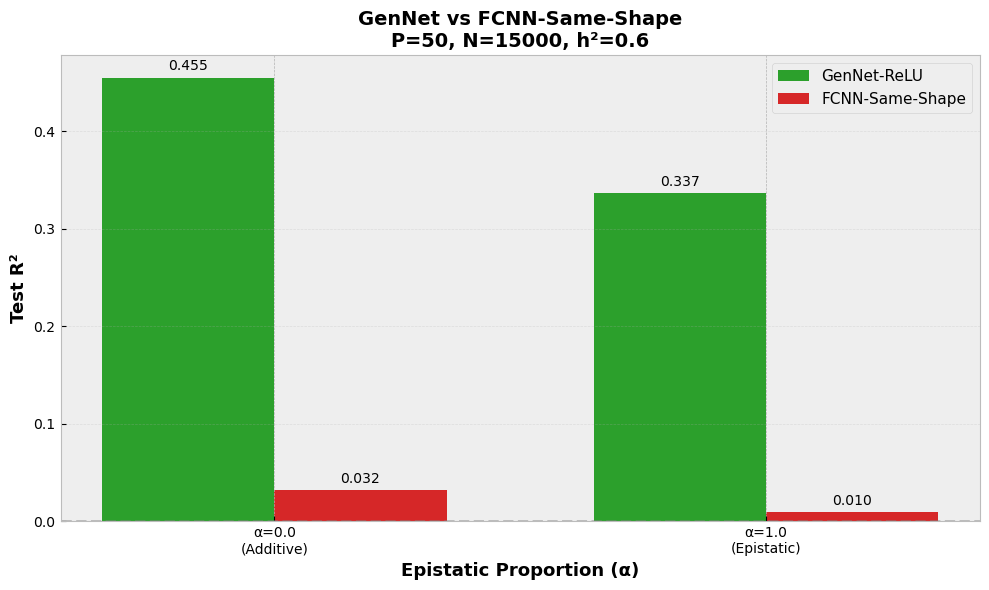


✓ Plot saved to: ../results/fcnn_experiments/gennet_vs_fcnn_comparison.png


In [13]:
# ============================================================
# Bar plot comparison: GenNet vs FCNN-Same-Shape
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for bar plot
bar_data = all_results.pivot_table(index='alpha', columns='model_type', values='test_r2')

x = np.arange(len(bar_data.index))
width = 0.35

bars1 = ax.bar(x - width/2, bar_data['GenNet-ReLU'], width, label='GenNet-ReLU', color='#2ca02c')
bars2 = ax.bar(x + width/2, bar_data['FCNN-Same-Shape'], width, label='FCNN-Same-Shape', color='#d62728')

ax.set_xlabel('Epistatic Proportion (α)', fontsize=13, fontweight='bold')
ax.set_ylabel('Test R²', fontsize=13, fontweight='bold')
ax.set_title(f'GenNet vs FCNN-Same-Shape\nP={p_values[0]}, N={n_train_values[0]}, h²=0.6', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'α={a}\n({"Additive" if a==0 else "Epistatic"})' for a in bar_data.index])
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(results_dir / 'gennet_vs_fcnn_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved to: {results_dir / 'gennet_vs_fcnn_comparison.png'}")

### Summary Statistics

In [14]:
print("="*70)
print("SUMMARY: GenNet vs FCNN-Same-Shape")
print("="*70)

# Calculate advantage
for alpha_val in alpha_values:
    gennet_r2 = all_results[(all_results['model_type'] == 'GenNet-ReLU') & 
                            (all_results['alpha'] == alpha_val)]['test_r2'].values[0]
    fcnn_r2 = all_results[(all_results['model_type'] == 'FCNN-Same-Shape') & 
                          (all_results['alpha'] == alpha_val)]['test_r2'].values[0]
    
    arch_type = 'Additive' if alpha_val == 0 else 'Epistatic'
    advantage = gennet_r2 - fcnn_r2
    winner = 'GenNet' if advantage > 0 else 'FCNN'
    
    print(f"\n{arch_type} (α={alpha_val}):")
    print(f"  GenNet-ReLU:      R² = {gennet_r2:.4f}")
    print(f"  FCNN-Same-Shape:  R² = {fcnn_r2:.4f}")
    print(f"  Difference:       {advantage:+.4f} ({winner} wins)")

SUMMARY: GenNet vs FCNN-Same-Shape

Additive (α=0):
  GenNet-ReLU:      R² = 0.4554
  FCNN-Same-Shape:  R² = 0.0320
  Difference:       +0.4233 (GenNet wins)

Epistatic (α=1):
  GenNet-ReLU:      R² = 0.3366
  FCNN-Same-Shape:  R² = 0.0098
  Difference:       +0.3268 (GenNet wins)


In [ ]:
print("\n" + "="*70)
print("EXPERIMENT COMPLETE")
print("="*70)
print(f"\nResults saved to: {results_dir}")
print(f"\nKey files:")
print(f"  - fcnn_same_shape_results.csv")
print(f"  - gennet_vs_fcnn_comparison.png")